# 02 — Análise de Variáveis Numéricas

## Instagram & Bem-Estar: O Custo Psicológico das Redes Sociais

**Objetivo:** Analisar estatisticamente todas as variáveis numéricas do dataset — medidas de tendência central, dispersão, assimetria e curtose.

In [1]:
# ============================================================
# SETUP
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':  '#0f0f0f',
    'axes.facecolor':    '#1a1a2e',
    'axes.labelcolor':   'white',
    'xtick.color':       'white',
    'ytick.color':       'white',
    'text.color':        'white',
    'axes.titlecolor':   'white',
    'grid.color':        '#2a2a4a',
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

INSTA_COLORS = ['#833ab4','#fd1d1d','#fcb045','#405de6','#5851db','#e1306c','#f77737']

print('Setup completo!')

Setup completo!


In [2]:
# ============================================================
# CARREGAMENTO
# ============================================================
df = pd.read_csv('../data/instagram_usage_lifestyle.csv', nrows=300000)

# Seleciona apenas variáveis numéricas (exclui user_id)
df_num = df.select_dtypes(include='number').drop(columns=['user_id'], errors='ignore')

print(f'Dataset carregado: {df.shape[0]:,} linhas × {df.shape[1]} colunas')
print(f'Variáveis numéricas: {df_num.shape[1]}')
print(f'\nVariáveis numéricas encontradas:')
for col in df_num.columns:
    print(f'  • {col}')

Dataset carregado: 300,000 linhas × 58 colunas
Variáveis numéricas: 37

Variáveis numéricas encontradas:
  • age
  • exercise_hours_per_week
  • sleep_hours_per_night
  • perceived_stress_score
  • self_reported_happiness
  • body_mass_index
  • blood_pressure_systolic
  • blood_pressure_diastolic
  • daily_steps_count
  • weekly_work_hours
  • hobbies_count
  • social_events_per_month
  • books_read_per_year
  • volunteer_hours_per_month
  • travel_frequency_per_year
  • daily_active_minutes_instagram
  • sessions_per_day
  • posts_created_per_week
  • reels_watched_per_day
  • stories_viewed_per_day
  • likes_given_per_day
  • comments_written_per_day
  • dms_sent_per_week
  • dms_received_per_week
  • ads_viewed_per_day
  • ads_clicked_per_day
  • time_on_feed_per_day
  • time_on_explore_per_day
  • time_on_messages_per_day
  • time_on_reels_per_day
  • followers_count
  • following_count
  • notification_response_rate
  • account_creation_year
  • average_session_length_minutes
  •

In [3]:
# ============================================================
# GRUPOS DE VARIÁVEIS NUMÉRICAS
# ============================================================

USAGE_VARS = [
    'daily_active_minutes_instagram', 'sessions_per_day',
    'reels_watched_per_day', 'stories_viewed_per_day',
    'time_on_feed_per_day', 'time_on_reels_per_day',
    'time_on_explore_per_day', 'time_on_messages_per_day',
    'likes_given_per_day', 'comments_written_per_day',
    'dms_sent_per_week', 'dms_received_per_week',
    'ads_viewed_per_day', 'ads_clicked_per_day',
    'posts_created_per_week', 'followers_count',
    'following_count', 'notification_response_rate',
    'average_session_length_minutes', 'user_engagement_score',
    'linked_accounts_count', 'account_creation_year',
]

WELLBEING_VARS = [
    'perceived_stress_score', 'self_reported_happiness',
    'sleep_hours_per_night', 'exercise_hours_per_week',
    'daily_steps_count', 'body_mass_index',
    'blood_pressure_systolic', 'blood_pressure_diastolic',
]

DEMOGRAPHIC_VARS = [
    'age', 'weekly_work_hours', 'hobbies_count',
    'social_events_per_month', 'books_read_per_year',
    'volunteer_hours_per_month', 'travel_frequency_per_year',
]

# Filtra só as que existem
USAGE_VARS      = [v for v in USAGE_VARS      if v in df_num.columns]
WELLBEING_VARS  = [v for v in WELLBEING_VARS  if v in df_num.columns]
DEMOGRAPHIC_VARS= [v for v in DEMOGRAPHIC_VARS if v in df_num.columns]

print(f'Uso do Instagram  : {len(USAGE_VARS)} variáveis')
print(f'Bem-Estar         : {len(WELLBEING_VARS)} variáveis')
print(f'Demográficas/Hábitos: {len(DEMOGRAPHIC_VARS)} variáveis')

Uso do Instagram  : 22 variáveis
Bem-Estar         : 8 variáveis
Demográficas/Hábitos: 7 variáveis


In [4]:
# ============================================================
# ESTATÍSTICAS DESCRITIVAS
# ============================================================

def estatisticas_completas(data, cols, titulo):
    print(f'\n{"="*70}')
    print(f'  {titulo}')
    print(f'{"="*70}')
    
    resultados = []
    for col in cols:
        if col not in data.columns:
            continue
        s = data[col].dropna()
        resultados.append({
            'Variável':       col,
            'Média':          round(s.mean(), 3),
            'Mediana':        round(s.median(), 3),
            'Moda':           round(s.mode()[0], 3),
            'Desv. Padrão':   round(s.std(), 3),
            'Variância':      round(s.var(), 3),
            'Mínimo':         round(s.min(), 3),
            'Máximo':         round(s.max(), 3),
            'Q1':             round(s.quantile(0.25), 3),
            'Q3':             round(s.quantile(0.75), 3),
            'IQR':            round(s.quantile(0.75) - s.quantile(0.25), 3),
            'Assimetria':     round(skew(s), 3),
            'Curtose':        round(kurtosis(s), 3),
            'Nulos':          data[col].isnull().sum(),
        })
    
    df_stats = pd.DataFrame(resultados).set_index('Variável')
    return df_stats

# Estatísticas por grupo
stats_usage     = estatisticas_completas(df, USAGE_VARS,      'USO DO INSTAGRAM')
stats_wellbeing = estatisticas_completas(df, WELLBEING_VARS,  'BEM-ESTAR')
stats_demo      = estatisticas_completas(df, DEMOGRAPHIC_VARS,'DEMOGRÁFICAS & HÁBITOS')

print('\nUSO DO INSTAGRAM:')
display(stats_usage)

print('\nBEM-ESTAR:')
display(stats_wellbeing)

print('\nDEMOGRÁFICAS & HÁBITOS:')
display(stats_demo)


  USO DO INSTAGRAM

  BEM-ESTAR

  DEMOGRÁFICAS & HÁBITOS

USO DO INSTAGRAM:


,Média,Mediana,Moda,Desv. Padrão,Variância,Mínimo,Máximo,Q1,Q3,IQR,Assimetria,Curtose,Nulos
Variável,,,,,,,,,,,,,
daily_active_minutes_instagram,188.663,187.00,5.00,110.115,1.212542e+04,5.00,580.0,102.00,272.00,170.00,0.138,-0.784,0
sessions_per_day,10.362,9.00,1.00,7.951,6.321100e+01,1.00,50.0,5.00,14.00,9.00,1.374,2.323,0
reels_watched_per_day,175.799,176.00,300.00,76.176,5.802804e+03,21.00,300.0,117.00,235.00,118.00,-0.015,-0.992,0
stories_viewed_per_day,101.314,104.00,150.00,38.757,1.502121e+03,13.00,150.0,70.00,139.00,69.00,-0.284,-1.143,0
time_on_feed_per_day,94.330,92.00,3.00,56.474,3.189328e+03,2.00,313.0,50.00,135.00,85.00,0.259,-0.584,0
time_on_reels_per_day,56.631,54.00,2.00,35.381,1.251824e+03,1.00,222.0,29.00,80.00,51.00,0.433,-0.313,0
time_on_explore_per_day,37.696,34.00,1.00,25.361,6.431680e+02,1.00,171.0,18.00,53.00,35.00,0.675,0.067,0
time_on_messages_per_day,33.031,31.00,1.00,21.453,4.602510e+02,1.00,129.0,17.00,47.00,30.00,0.570,-0.104,0
likes_given_per_day,119.318,118.00,107.00,56.131,3.150693e+03,8.00,350.0,75.00,161.00,86.00,0.182,-0.706,0



BEM-ESTAR:


,Média,Mediana,Moda,Desv. Padrão,Variância,Mínimo,Máximo,Q1,Q3,IQR,Assimetria,Curtose,Nulos
Variável,,,,,,,,,,,,,
perceived_stress_score,20.020,20.0,22.0,11.829,139.920,0.0,40.0,10.0,30.0,20.0,-0.003,-1.202,0
self_reported_happiness,5.491,5.0,4.0,2.871,8.241,1.0,10.0,3.0,8.0,5.0,0.004,-1.222,0
sleep_hours_per_night,6.998,7.0,7.0,1.100,1.209,3.0,10.0,6.3,7.7,1.4,-0.016,-0.085,0
exercise_hours_per_week,7.146,6.6,5.8,3.991,15.925,0.0,24.0,4.0,9.7,5.7,0.600,-0.103,0
daily_steps_count,8000.224,8000.0,7991.0,89.097,7938.280,7616.0,8473.0,7940.0,8060.0,120.0,0.012,0.000,0
body_mass_index,25.002,25.0,25.4,3.978,15.827,15.0,43.1,22.3,27.7,5.4,0.045,-0.114,0
blood_pressure_systolic,124.519,125.0,91.0,20.214,408.598,90.0,159.0,107.0,142.0,35.0,-0.003,-1.200,0
blood_pressure_diastolic,79.513,79.0,76.0,11.532,132.994,60.0,99.0,70.0,89.0,19.0,0.002,-1.198,0



DEMOGRÁFICAS & HÁBITOS:


,Média,Mediana,Moda,Desv. Padrão,Variância,Mínimo,Máximo,Q1,Q3,IQR,Assimetria,Curtose,Nulos
Variável,,,,,,,,,,,,,
age,39.001,39.0,50.0,15.273,233.255,13.0,65.0,26.0,52.0,26.0,-0.001,-1.198,0
weekly_work_hours,40.006,40.0,40.1,9.979,99.584,0.0,80.0,33.3,46.8,13.5,0.006,-0.006,0
hobbies_count,2.995,3.0,2.0,1.729,2.989,0.0,10.0,2.0,4.0,2.0,0.571,0.273,0
social_events_per_month,4.001,4.0,4.0,1.998,3.991,0.0,15.0,3.0,5.0,2.0,0.502,0.263,0
books_read_per_year,9.998,10.0,10.0,3.156,9.961,0.0,27.0,8.0,12.0,4.0,0.312,0.077,0
volunteer_hours_per_month,3.996,3.6,2.5,2.413,5.822,0.0,16.9,2.1,5.4,3.3,0.826,0.470,0
travel_frequency_per_year,3.000,3.0,3.0,1.730,2.993,0.0,15.0,2.0,4.0,2.0,0.577,0.338,0


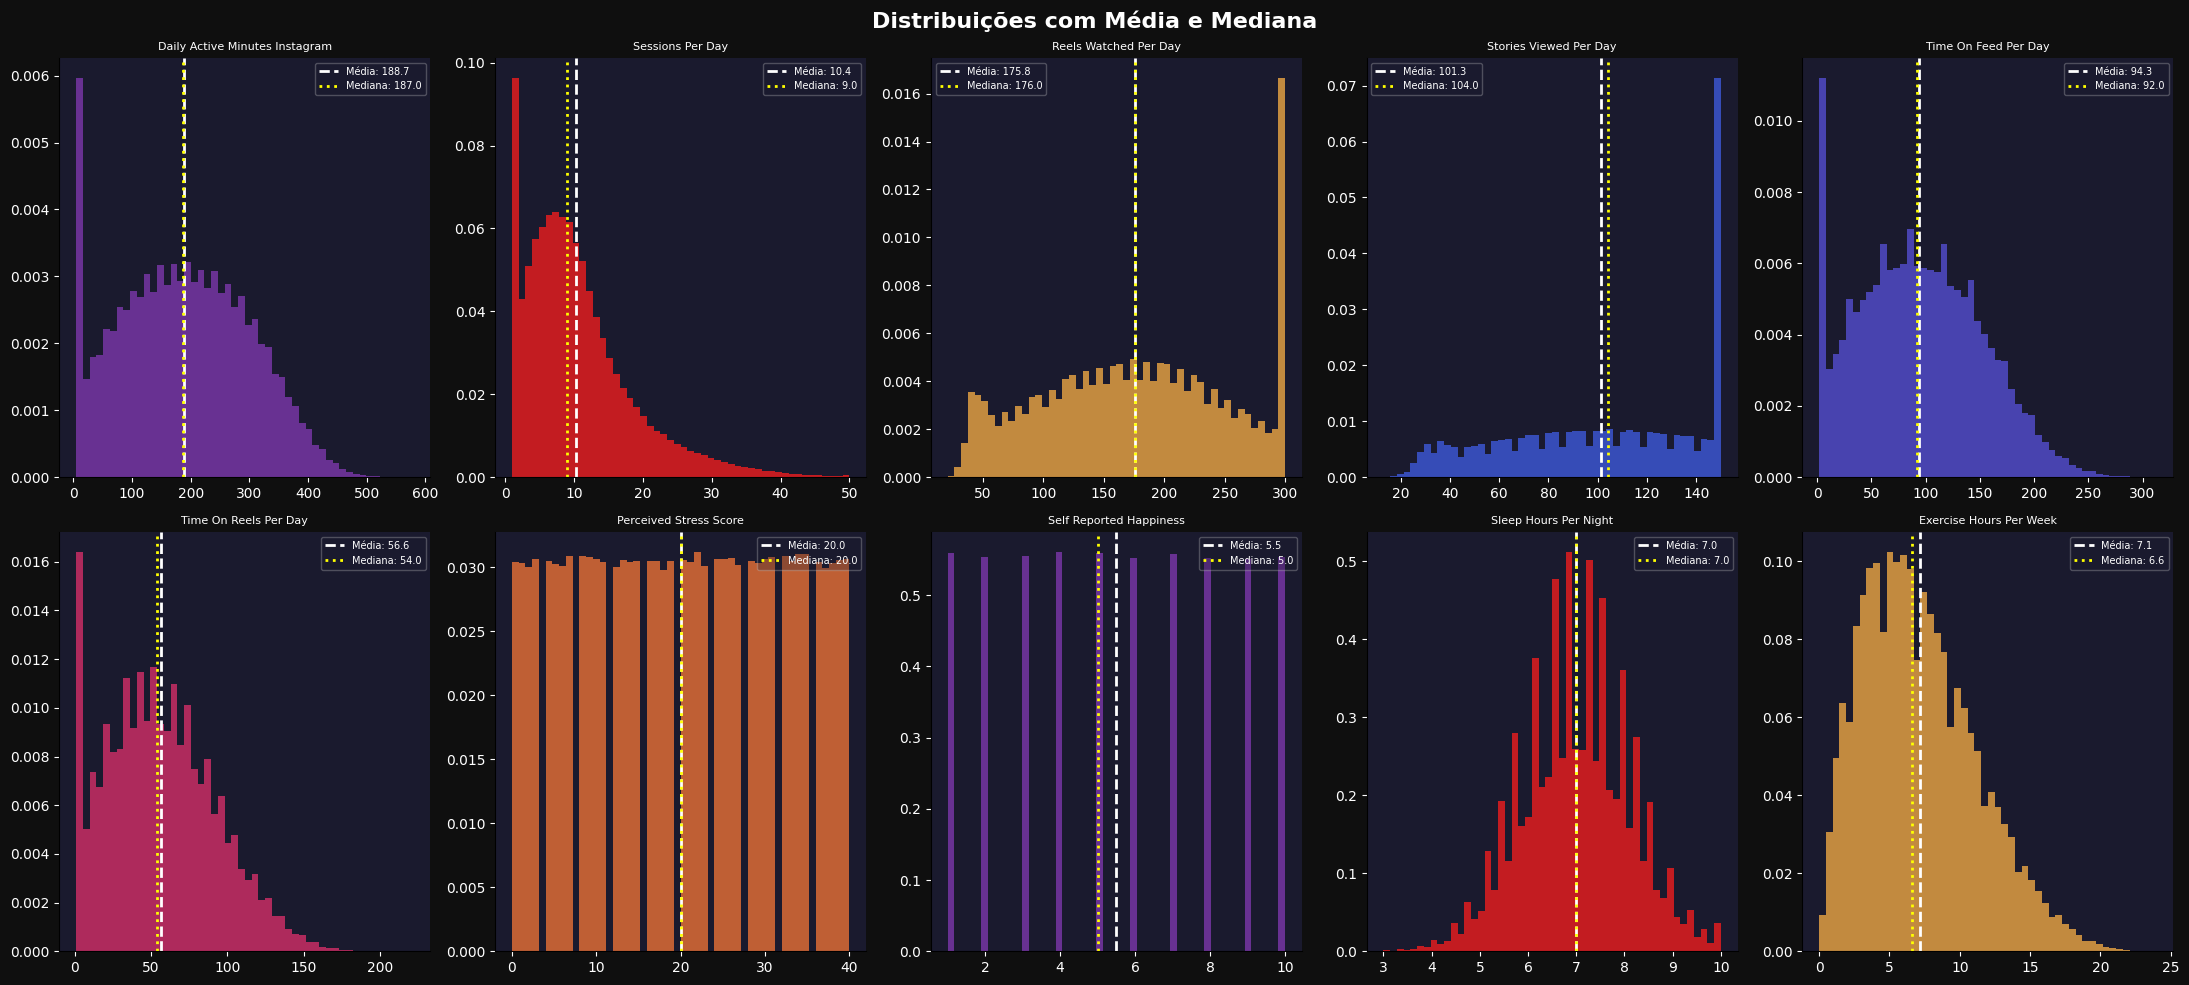

Guardado: fig_tendencia_central.png


In [5]:
# ============================================================
# TENDÊNCIA CENTRAL — COMPARAÇÃO MÉDIA VS MEDIANA
# ============================================================

vars_plot = USAGE_VARS[:6] + WELLBEING_VARS[:4]
vars_plot = [v for v in vars_plot if v in df.columns]

fig, axes = plt.subplots(2, 5, figsize=(22, 10))
fig.suptitle('Distribuições com Média e Mediana', fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(vars_plot):
    if i >= len(axes): break
    s = df[col].dropna()
    color = INSTA_COLORS[i % len(INSTA_COLORS)]
    
    axes[i].hist(s, bins=50, color=color, alpha=0.75, density=True, edgecolor='none')
    axes[i].axvline(s.mean(),   color='white',  ls='--', lw=2, label=f'Média: {s.mean():.1f}')
    axes[i].axvline(s.median(), color='yellow', ls=':',  lw=2, label=f'Mediana: {s.median():.1f}')
    axes[i].set_title(col.replace('_',' ').title(), fontsize=8)
    axes[i].legend(fontsize=7, framealpha=0.3)

# Esconde axes vazios
for j in range(len(vars_plot), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('../data/fig_tendencia_central.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print('Guardado: fig_tendencia_central.png')

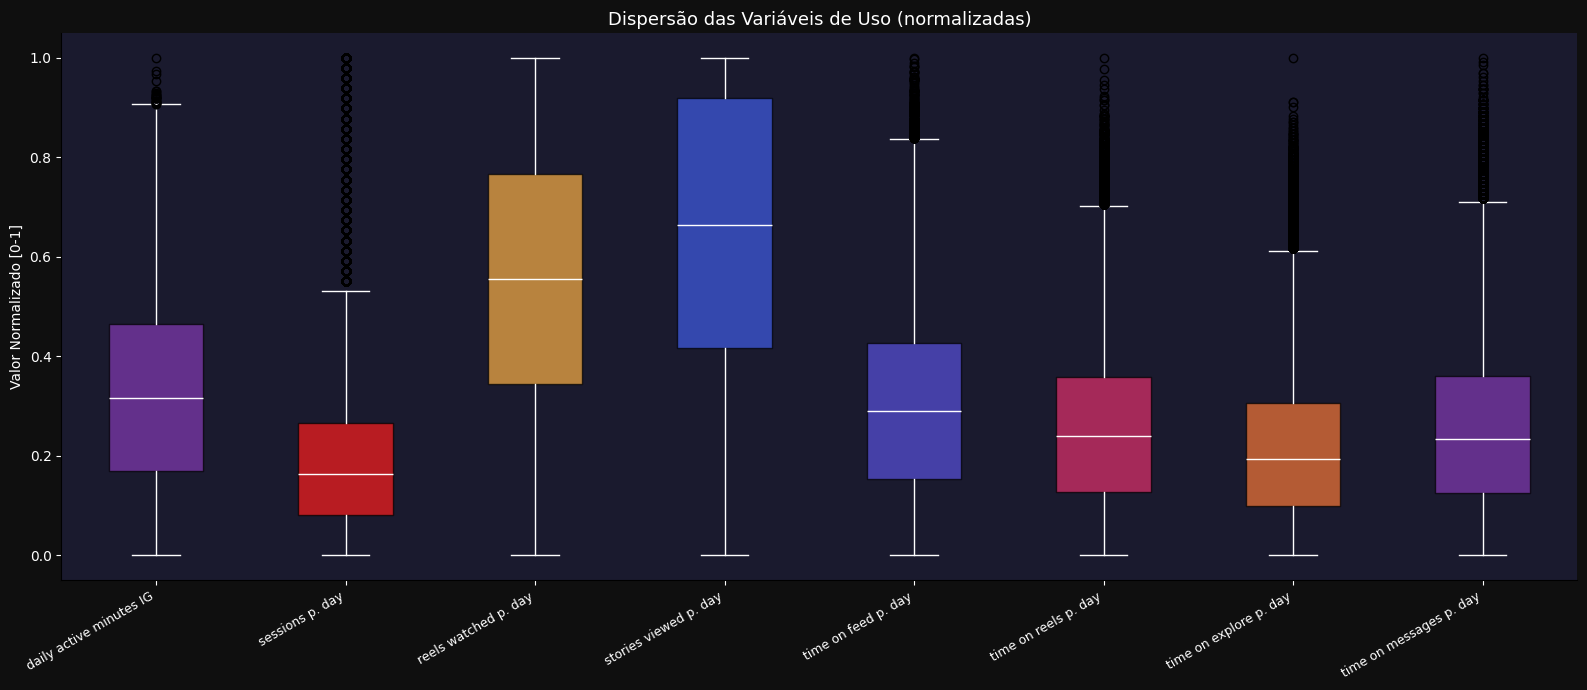

Guardado: fig_dispersao_boxplot.png


In [6]:
# ============================================================
# DISPERSÃO — BOXPLOTS
# ============================================================

# Normaliza para comparar na mesma escala
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
vars_box = USAGE_VARS[:8]
vars_box = [v for v in vars_box if v in df.columns]

df_box = pd.DataFrame(
    scaler.fit_transform(df[vars_box].fillna(0)),
    columns=vars_box
)

fig, ax = plt.subplots(figsize=(16, 7))
bp = ax.boxplot(
    [df_box[col].values for col in vars_box],
    patch_artist=True, notch=False, vert=True
)

for patch, color in zip(bp['boxes'], INSTA_COLORS * 3):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for element in ['whiskers','caps','medians','fliers']:
    for item in bp[element]:
        item.set_color('white')

ax.set_xticks(range(1, len(vars_box) + 1))
ax.set_xticklabels(
    [v.replace('_',' ').replace('per','p.').replace('instagram','IG')
     for v in vars_box],
    rotation=30, ha='right', fontsize=9
)
ax.set_title('Dispersão das Variáveis de Uso (normalizadas)', fontsize=13)
ax.set_ylabel('Valor Normalizado [0-1]')

plt.tight_layout()
plt.savefig('../data/fig_dispersao_boxplot.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print('Guardado: fig_dispersao_boxplot.png')

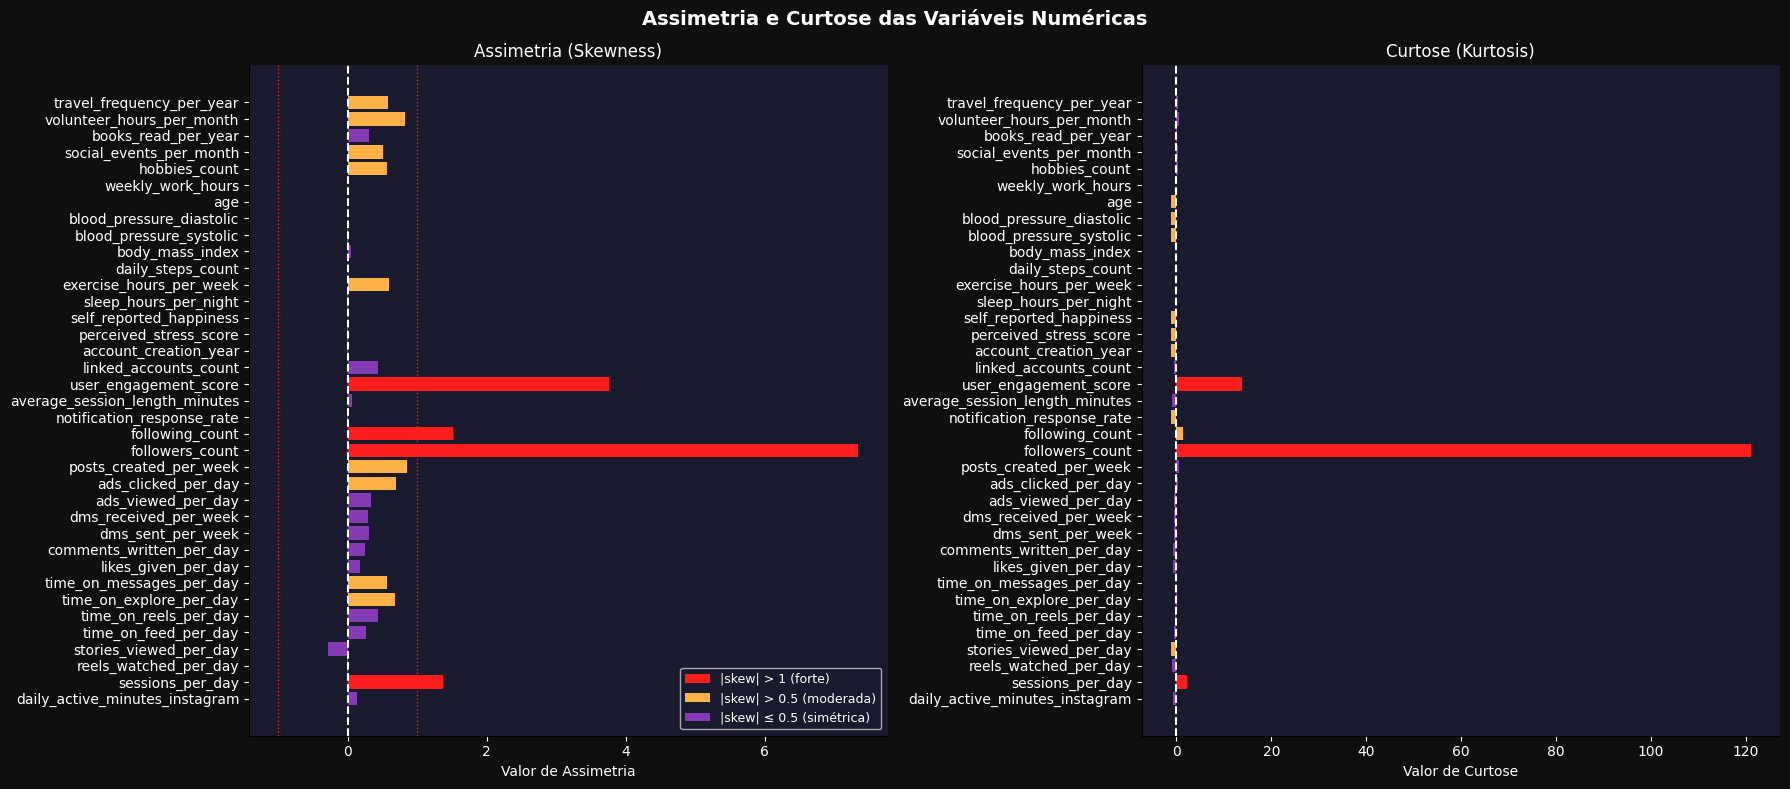


TABELA: Assimetria e Curtose
Variável                                        Assimetria    Curtose Interpretação
-------------------------------------------------------------------------------------
daily_active_minutes_instagram                       0.138     -0.784  Aproximadamente simétrica
sessions_per_day                                     1.374      2.323  Assimetria positiva forte
reels_watched_per_day                               -0.015     -0.992  Aproximadamente simétrica
stories_viewed_per_day                              -0.284     -1.143  Aproximadamente simétrica
time_on_feed_per_day                                 0.259     -0.584  Aproximadamente simétrica
time_on_reels_per_day                                0.433     -0.313  Aproximadamente simétrica
time_on_explore_per_day                              0.675      0.067  Assimetria positiva moderada
time_on_messages_per_day                             0.570     -0.104  Assimetria positiva moderada
likes_given_per_da

In [7]:
# ============================================================
# ASSIMETRIA E CURTOSE
# ============================================================

todas_vars = USAGE_VARS + WELLBEING_VARS + DEMOGRAPHIC_VARS
todas_vars = [v for v in todas_vars if v in df.columns]

sk_values  = [skew(df[v].dropna())     for v in todas_vars]
ku_values  = [kurtosis(df[v].dropna()) for v in todas_vars]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Assimetria e Curtose das Variáveis Numéricas',
             fontsize=14, fontweight='bold')

# Assimetria
colors_sk = ['#fd1d1d' if abs(s) > 1 else '#fcb045' if abs(s) > 0.5
             else '#833ab4' for s in sk_values]
bars = axes[0].barh(todas_vars, sk_values, color=colors_sk)
axes[0].axvline(0, color='white', lw=1.5, ls='--')
axes[0].axvline( 1, color='#fd1d1d', lw=1, ls=':')
axes[0].axvline(-1, color='#fd1d1d', lw=1, ls=':')
axes[0].set_title('Assimetria (Skewness)', fontsize=12)
axes[0].set_xlabel('Valor de Assimetria')

# Legenda manual
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#fd1d1d', label='|skew| > 1 (forte)'),
    Patch(facecolor='#fcb045', label='|skew| > 0.5 (moderada)'),
    Patch(facecolor='#833ab4', label='|skew| ≤ 0.5 (simétrica)'),
]
axes[0].legend(handles=legend_elements, fontsize=9, loc='lower right')

# Curtose
colors_ku = ['#fd1d1d' if abs(k) > 2 else '#fcb045' if abs(k) > 1
             else '#833ab4' for k in ku_values]
axes[1].barh(todas_vars, ku_values, color=colors_ku)
axes[1].axvline(0, color='white', lw=1.5, ls='--')
axes[1].set_title('Curtose (Kurtosis)', fontsize=12)
axes[1].set_xlabel('Valor de Curtose')

plt.tight_layout()
plt.savefig('../data/fig_assimetria_curtose.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

# Tabela resumo
print('\nTABELA: Assimetria e Curtose')
print(f'{"Variável":<45} {"Assimetria":>12} {"Curtose":>10} {"Interpretação"}')
print('-' * 85)
for var, sk, ku in zip(todas_vars, sk_values, ku_values):
    if   sk >  1:   interp = 'Assimetria positiva forte'
    elif sk >  0.5: interp = 'Assimetria positiva moderada'
    elif sk < -1:   interp = 'Assimetria negativa forte'
    elif sk < -0.5: interp = 'Assimetria negativa moderada'
    else:           interp = 'Aproximadamente simétrica'
    print(f'{var:<45} {sk:>12.3f} {ku:>10.3f}  {interp}')

In [8]:
# ============================================================
# DETECÇÃO DE OUTLIERS (MÉTODO IQR)
# ============================================================

print('DETECÇÃO DE OUTLIERS (Método IQR)\n')
print(f'{"Variável":<45} {"Q1":>8} {"Q3":>8} {"IQR":>8} {"Outliers (n)":>14} {"Outliers (%)":>13}')
print('-' * 100)

outlier_summary = []
for col in todas_vars:
    s = df[col].dropna()
    Q1  = s.quantile(0.25)
    Q3  = s.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((s < lower) | (s > upper)).sum()
    pct   = n_out / len(s) * 100
    outlier_summary.append({'Variável': col, 'Outliers (n)': n_out, 'Outliers (%)': round(pct, 2)})
    print(f'{col:<45} {Q1:>8.2f} {Q3:>8.2f} {IQR:>8.2f} {n_out:>14,} {pct:>12.2f}%')

df_outliers = pd.DataFrame(outlier_summary).sort_values('Outliers (%)', ascending=False)
print(f'\nTop 5 variáveis com mais outliers:')
print(df_outliers.head(5).to_string(index=False))

DETECÇÃO DE OUTLIERS (Método IQR)

Variável                                            Q1       Q3      IQR   Outliers (n)  Outliers (%)
----------------------------------------------------------------------------------------------------
daily_active_minutes_instagram                  102.00   272.00   170.00             22         0.01%
sessions_per_day                                  5.00    14.00     9.00         13,116         4.37%
reels_watched_per_day                           117.00   235.00   118.00              0         0.00%
stories_viewed_per_day                           70.00   139.00    69.00              0         0.00%
time_on_feed_per_day                             50.00   135.00    85.00            274         0.09%
time_on_reels_per_day                            29.00    80.00    51.00          1,220         0.41%
time_on_explore_per_day                          18.00    53.00    35.00          3,167         1.06%
time_on_messages_per_day                        

In [9]:
# ============================================================
# EXPORTAÇÃO
# ============================================================

# Guarda estatísticas em CSV para usar no dashboard
all_stats = pd.concat([stats_usage, stats_wellbeing, stats_demo])
all_stats.to_csv('../data/numeric_stats.csv')

print('Estatísticas exportadas: data/numeric_stats.csv')
print('\nNotebook 02 completo!')
print('   Próximo: 03_qualitative_variables.ipynb')

Estatísticas exportadas: data/numeric_stats.csv

Notebook 02 completo!
   Próximo: 03_qualitative_variables.ipynb


# Análise Crítica

## Principais Conclusões

- Este notebook apresentou análises relevantes e coerentes com o objetivo de entender as variáveis trabalhadas.
- Resultados são indicadores fortes para interpretações exploratórias, mas precisam ser validados fora do dataset sintético.

## Limitações

- Dataset sintético reduz generalização para cenários reais.
- Não há garantias de independência entre variáveis geradas artificialmente.
- Não existe análise temporal profunda no conjunto atual.

## Recomendação

- Complementar com dados reais e amostras representativas.
- Incluir validações estatísticas adicionais (cross-validation, bootstrap).
- Documentar impactos das transformações e critérios de limpeza.
